In [1]:
using ModularEIT
using FFTW
using Images
using Ferrite
using Enzyme
using LinearAlgebra


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
n = 63
#grid = generate_grid(Triangle, (n, n))
grid = generate_grid(Quadrilateral, (n, n))
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)

println("Type of ∂Ω: $(typeof(∂Ω))")
#fe = FerriteFESpace{RefTriangle}(grid, 2, 3, ∂Ω)
fe = FerriteFESpace{RefQuadrilateral}(grid, 2, 3, ∂Ω)
img = load("../../test/SolverTests/Reference2Spot.jpg")
itp = interpolate_array_2D(Float64.(img))
cond_vec = project_function_to_fem(fe, itp)

Type of ∂Ω: OrderedCollections.OrderedSet{FacetIndex}


16129-element Vector{Float64}:
 0.5254901960784308
 0.5254901960784311
 0.5254901960784314
 0.5254901960784311
 0.5254901960784318
 0.5254901960784315
 0.5254901960784317
 0.5254901960784316
 0.5254901960784314
 0.525490196078431
 ⋮
 0.5254901960784312
 0.5254901960784315
 0.5254901960784314
 0.5254901960784312
 0.5254901960784314
 0.5254901960784315
 0.5254901960784317
 0.5254901960784316
 0.5254901960784311

In [3]:
G_full = real_fourier_basis(8)

256×256 Matrix{Float64}:
 0.0625  0.0883883   0.0         …   0.0883883   0.0          0.0625
 0.0625  0.0883617   0.00216916     -0.0883617   0.00216916  -0.0625
 0.0625  0.0882819   0.00433701      0.0882819  -0.00433701   0.0625
 0.0625  0.0881489   0.00650225     -0.0881489   0.00650225  -0.0625
 0.0625  0.0879627   0.00866357      0.0879627  -0.00866357   0.0625
 0.0625  0.0877236   0.0108197   …  -0.0877236   0.0108197   -0.0625
 0.0625  0.0874317   0.0129693       0.0874317  -0.0129693    0.0625
 0.0625  0.0870871   0.015111       -0.0870871   0.015111    -0.0625
 0.0625  0.08669     0.0172437       0.08669    -0.0172437    0.0625
 0.0625  0.0862407   0.019366       -0.0862407   0.019366    -0.0625
 ⋮                               ⋱                            ⋮
 0.0625  0.0862407  -0.019366       -0.0862407  -0.019366    -0.0625
 0.0625  0.08669    -0.0172437       0.08669     0.0172437    0.0625
 0.0625  0.0870871  -0.015111       -0.0870871  -0.015111    -0.0625
 0.0625  0.087

In [4]:
G_full = real_fourier_basis(8)
rhs_vec = Vector{Any}(undef, 255)

Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i], 64)
    itp = interpolate_array_2D(M)
    rhs_vec[i-1] = assemble_rhs_func(fe, itp)
end
# Assemble stiffness matrix and calculate boundary pairs:
K = assemble_L(fe, cond_vec)
K_fac = factorize(K)

mode_vec = Vector{Any}(undef, 255)
for i in 1:255
    mode_vec[i] = create_mode_from_g(fe, rhs_vec[i], K)
end
# define starting guess and define problem:
σ_vec = project_function_to_fem(fe, x -> 0.5)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_vec, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [5]:
σ₀ = copy(prblm.state.σ)


16129-element Vector{Float64}:
 0.5000000000000001
 0.5000000000000002
 0.5000000000000001
 0.49999999999999994
 0.5
 0.5000000000000001
 0.5000000000000001
 0.5000000000000002
 0.5
 0.5
 ⋮
 0.5
 0.49999999999999956
 0.5000000000000003
 0.5000000000000002
 0.4999999999999998
 0.4999999999999998
 0.5000000000000003
 0.5000000000000003
 0.4999999999999999

In [6]:
ρ = 10.0
f, ∂f = create_f∂f(prblm, 200; gn=true)
prox_f = create_prox_linesearch(f,∂f,ρ)
#prox_f = create_proximal_gradient_step(f,∂f,ρ)

#65 (generic function with 1 method)

In [7]:
TV = (x) -> normTV(prblm.fe, x)
∇TV = (x) -> assemble_huber_gradient(prblm.fe, x)
prox_TV = create_proximal_gradient_step(TV, ∇TV,ρ)

#75 (generic function with 1 method)

In [8]:
err = f(σ₀)

0.09464158483936433

In [9]:
∂f(σ₀)

16129-element Vector{Float64}:
 0.03346989928928004
 0.034141355266622216
 0.03462396309627522
 0.03464903930628561
 0.034222293345395546
 0.03339176135187748
 0.032206797122511385
 0.03070995025841819
 0.0289370296663799
 0.026918969336435374
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [12]:
# ADMM
x = copy(σ₀)
z = copy(σ₀)
u = zeros(fe.n)

for i in 1:3
    x, _= prox_f(z-u)
    z = prox_TV(x+u)
    @. u += x - z
    println("$i")
    #println("$err reconstruction error, $err_TV - regularization error - $i")
end

Iter 1 - Loss: 0.000250258534188826
Iter 2 - Loss: 0.00018589355451490753
Iter 3 - Loss: 0.00015302314070306385
Iter 4 - Loss: 0.00015079129196357918
Iter 5 - Loss: 0.000143028487201041
Iter 6 - Loss: 0.00013851774313511028
Iter 7 - Loss: 0.00013382399166736878
Iter 8 - Loss: 0.00013254654605158214
Iter 9 - Loss: 0.00013069203679709265
Iter 10 - Loss: 0.0001305308721105251
Iter 11 - Loss: 0.0001287688269408282
Iter 12 - Loss: 0.00012745342557452926
Iter 13 - Loss: 0.00012584966493781844
Iter 14 - Loss: 0.00012480523812037443
Iter 15 - Loss: 0.00012348995606554835
Iter 16 - Loss: 0.00012238691707962813
Iter 17 - Loss: 0.00012145386410059783
Iter 18 - Loss: 0.0001200345609391494
Iter 19 - Loss: 0.00011902586932068693
Iter 20 - Loss: 0.00011801097740788719
Iter 21 - Loss: 0.00011702894081927533
Iter 22 - Loss: 0.00011618172064287753
Iter 23 - Loss: 0.00011518315276652037
Iter 24 - Loss: 0.00011442070194414655
Iter 25 - Loss: 0.0001132720558965428
Iter 26 - Loss: 0.000111860755592409
Iter 

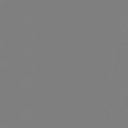

In [14]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)
img_final = Gray.(max.(0.0, min.(1.0, reshape(evaluate_at_points(ph, prblm.fe.dh, x), (64, 64)))))